In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aadigupta1601/f1-strategy-dataset-pit-stop-prediction")

print("Path to dataset files:", path)

/Users/abdullahalhossain/Jupyter/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 2.59M/2.59M [00:01<00:00, 1.64MB/s]

Extracting files...
Path to dataset files: /Users/abdullahalhossain/.cache/kagglehub/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/versions/4


In [59]:
import pandas as pd
import os 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [41]:
df=pd.read_csv("f1_strategy_dataset_v4.csv")
print(df.columns)

Index(['Driver', 'LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position',
       'LapTime (s)', 'Race', 'Year', 'LapTime_Delta',
       'Cumulative_Degradation', 'PitStop', 'PitNextLap', 'RaceProgress',
       'Normalized_TyreLife', 'Position_Change'],
      dtype='object')


In [6]:
print(len(df))

101371


In [ ]:
 #------ USE CASE : 1 ------------ (Predicting Pit Stop Decisions)

In [10]:
print(len(df.loc[df['PitNextLap'] == 1]))

# This sorts the Abu Dhabi race by TyreLife descending and shows the top 5 oldest tires
print(df[df['Race'] == "Abu Dhabi Grand Prix"][['Driver', 'Compound', 'TyreLife']].sort_values(by='TyreLife', ascending=False).head(5))

25829
      Driver Compound  TyreLife
25315    HUL     HARD      45.0
24970    ALB     HARD      45.0
25199    GAS     HARD      44.0
52702    BEA     HARD      44.0
24969    ALB     HARD      44.0


Connecting to F1 servers for 2023 Abu Dhabi Grand Prix...


core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No 

DataNotLoadedError: The data you are trying to access has not been loaded yet. See `Session.load`

In [4]:
race_starts = df[df['LapNumber'] == 1][['Year', 'Race', 'Driver', 'Compound', 'Position']].copy()
print(race_starts)

        Year                      Race Driver Compound  Position
0       2023      Abu Dhabi Grand Prix    ALB   MEDIUM        17
58      2023      Abu Dhabi Grand Prix    ALO   MEDIUM         7
116     2023      Abu Dhabi Grand Prix    BOT     HARD        16
173     2023      Abu Dhabi Grand Prix    GAS   MEDIUM         8
231     2023      Abu Dhabi Grand Prix    HAM   MEDIUM         9
...      ...                       ...    ...      ...       ...
101145  2022  United States Grand Prix    STR   MEDIUM         3
101164  2022  United States Grand Prix    TSU   MEDIUM        14
101217  2022  United States Grand Prix    VER   MEDIUM         1
101267  2022  United States Grand Prix    VET   MEDIUM         5
101317  2022  United States Grand Prix    ZHO   MEDIUM        17

[1829 rows x 5 columns]


In [12]:
last_lap_idx = df.groupby(['Year', 'Race', 'Driver','Compound'])['LapNumber'].idxmax()
print(last_lap_idx.head())

Year  Race                   Driver  Compound
2022  Australian Grand Prix  ALB     HARD        79567
                                     SOFT        79568
                             ALO     HARD        79606
                                     MEDIUM      79624
                             BOT     HARD        79681
Name: LapNumber, dtype: int64


In [13]:
final_position= df.loc[last_lap_idx]
print(final_position.sort_values(by='Position', ascending=True).head(10))

      Driver  LapNumber Compound  Stint  TyreLife  Position  LapTime (s)  \
79510    VER         56     SOFT      2      25.0         1       98.260   
31472    HAM         52     SOFT      3      15.0         1       90.146   
70022    PIA         57     HARD      2      25.0         1       90.441   
69997    PIA         32   MEDIUM      1       8.0         1       90.211   
57317    PIA         14     SOFT      1      17.0         1      101.297   
57359    PIA         57   MEDIUM      3      25.0         1       96.588   
96966    HAM         33   MEDIUM      2      32.0         1       92.256   
97057    LEC         25   MEDIUM      2      24.0         1       92.501   
31041    RUS         44     HARD      2      34.0         1      107.113   
86138    VER         70     HARD      3      27.0         1       75.916   

                           Race  Year  LapTime_Delta  Cumulative_Degradation  \
79510  United States Grand Prix  2025          1.594                -194.554   
314

In [ ]:
winners= final_position[(final_position['Position'] == 1 ) & (final_position['Compound'] == 'SOFT')]
print(winners[['Year','Race']])


        Year                       Race
82814   2022         Bahrain Grand Prix
84130   2022         Belgian Grand Prix
84815   2022         British Grand Prix
87522   2022           Dutch Grand Prix
88667   2022  Emilia Romagna Grand Prix
92024   2022         Italian Grand Prix
97412   2022   Pre-Season Track Session
99633   2022         Spanish Grand Prix
100337  2022         Spanish Grand Prix
3339    2023        Austrian Grand Prix
5317    2023         Bahrain Grand Prix
6165    2023         Belgian Grand Prix
7123    2023         British Grand Prix
9692    2023           Dutch Grand Prix
18460   2023         Pre-Season Testing
22744   2023         Spanish Grand Prix
23878   2023       São Paulo Grand Prix
30369   2024         Bahrain Grand Prix
31472   2024         British Grand Prix
50277   2024         Spanish Grand Prix
57317   2025         Bahrain Grand Prix
69102   2025     Mexico City Grand Prix
76931   2025         Spanish Grand Prix
77926   2025       São Paulo Grand Prix


In [21]:
most_won_soft_tracks = winners['Race'].value_counts().reset_index()

# 3. Rename the columns for a clean presentation
most_won_soft_tracks.columns = ['Racetrack', 'Wins on SOFT Tires']

# 4. Print the final leaderboard
print("--- Racetracks with the Most Wins on SOFT Tires ---")
print(most_won_soft_tracks.to_string(index=False))

--- Racetracks with the Most Wins on SOFT Tires ---
                Racetrack  Wins on SOFT Tires
       Spanish Grand Prix                   5
       Bahrain Grand Prix                   4
       British Grand Prix                   3
       Belgian Grand Prix                   2
         Dutch Grand Prix                   2
     São Paulo Grand Prix                   2
Emilia Romagna Grand Prix                   1
       Italian Grand Prix                   1
 Pre-Season Track Session                   1
      Austrian Grand Prix                   1
       Pre-Season Testing                   1
   Mexico City Grand Prix                   1
 United States Grand Prix                   1


In [22]:
winners= final_position[(final_position['Position'] == 1 ) & (final_position['Compound'] == 'HARD')]
most_won_soft_tracks = winners['Race'].value_counts().reset_index()
print(most_won_soft_tracks.to_string(index=False))


                     Race  count
 United States Grand Prix      5
      Austrian Grand Prix      5
    Australian Grand Prix      4
    Azerbaijan Grand Prix      4
         Miami Grand Prix      4
     Hungarian Grand Prix      4
 Saudi Arabian Grand Prix      4
     Singapore Grand Prix      3
         Qatar Grand Prix      3
     Las Vegas Grand Prix      3
      Japanese Grand Prix      3
       Italian Grand Prix      3
     Abu Dhabi Grand Prix      3
        Monaco Grand Prix      3
         Dutch Grand Prix      3
      Canadian Grand Prix      3
       Bahrain Grand Prix      2
          Pre-Season Test      2
   Mexico City Grand Prix      2
       Chinese Grand Prix      2
Emilia Romagna Grand Prix      2
       Pre-Season Testing      2
 Pre-Season Track Session      1
        French Grand Prix      1
       British Grand Prix      1
       Spanish Grand Prix      1
       Belgian Grand Prix      1


In [23]:
winners= final_position[(final_position['Position'] == 1 ) & (final_position['Compound'] == 'MEDIUM')]
most_won_soft_tracks = winners['Race'].value_counts().reset_index()
print(most_won_soft_tracks.to_string(index=False))

                     Race  count
   Mexico City Grand Prix      7
       Italian Grand Prix      7
 United States Grand Prix      7
       British Grand Prix      6
     Abu Dhabi Grand Prix      5
       Spanish Grand Prix      5
     Singapore Grand Prix      5
 Saudi Arabian Grand Prix      5
         Miami Grand Prix      5
      Japanese Grand Prix      5
     Hungarian Grand Prix      5
    Azerbaijan Grand Prix      5
     Las Vegas Grand Prix      4
         Qatar Grand Prix      4
      Austrian Grand Prix      4
Emilia Romagna Grand Prix      4
       Belgian Grand Prix      4
     São Paulo Grand Prix      4
       Pre-Season Testing      4
        Monaco Grand Prix      3
 Pre-Season Track Session      3
         Dutch Grand Prix      3
    Australian Grand Prix      3
       Chinese Grand Prix      2
      Canadian Grand Prix      2
        French Grand Prix      2
       Bahrain Grand Prix      2
          Pre-Season Test      1


In [26]:
print(df.head(),df.tail(),sep='\n')

  Driver  LapNumber Compound  Stint  TyreLife  Position  LapTime (s)  \
0    ALB          1   MEDIUM      1       2.0        17      100.625   
1    ALB          2   MEDIUM      1       3.0        18       93.560   
2    ALB          3   MEDIUM      1       4.0        18       91.768   
3    ALB          4   MEDIUM      1       5.0        18       91.591   
4    ALB          5   MEDIUM      1       6.0        18       91.422   

                   Race  Year  LapTime_Delta  Cumulative_Degradation  PitStop  \
0  Abu Dhabi Grand Prix  2023          0.000                   0.000        0   
1  Abu Dhabi Grand Prix  2023         -7.065                  -7.065        0   
2  Abu Dhabi Grand Prix  2023         -1.792                  -8.857        0   
3  Abu Dhabi Grand Prix  2023         -0.177                  -9.034        0   
4  Abu Dhabi Grand Prix  2023         -0.169                  -9.203        0   

   PitNextLap  RaceProgress  Normalized_TyreLife  Position_Change  
0           

In [33]:
df['Compound_Changed'] = df.groupby(['Year', 'Race', 'Driver'])['Compound'].shift(1) != df['Compound']
df['Pit_Triggered'] = df.groupby(['Year', 'Race', 'Driver'])['PitStop'].shift(1) == 1

# A new stint starts if either condition is True. We use .cumsum() to create incrementing numbers (1, 2, 3...)
df['Stint'] = df.groupby(['Year', 'Race', 'Driver'])['Compound_Changed'].cumsum() + 1

print(df['Stint'].value_counts().reset_index())

    Stint  count
0       3  50749
1       2  37624
2       4  11721
3       5   1019
4       6    155
5       7     44
6      28      2
7      23      2
8      24      2
9      25      2
10     26      2
11     27      2
12     31      2
13     29      2
14     30      2
15     32      2
16     33      2
17     34      2
18     22      2
19     21      2
20     20      2
21     13      2
22      8      2
23      9      2
24     10      2
25     19      2
26     12      2
27     11      2
28     14      2
29     15      2
30     16      2
31     17      2
32     18      2
33     35      1
34     36      1
35     37      1
36     38      1
37     39      1


In [39]:

finishing = df.loc[(df['Compound'] == 'SOFT') & (df['Position'] == 1) & (df['LapNumber'] == 58),['Year','Race','Driver']]

print(finishing.reset_index())

   index  Year                       Race Driver
0   9689  2023           Dutch Grand Prix    VER
1  22736  2023         Spanish Grand Prix    VER
2  50269  2024         Spanish Grand Prix    VER
3  76923  2025         Spanish Grand Prix    PIA
4  88662  2022  Emilia Romagna Grand Prix    VER


In [40]:
finishing = df.loc[(df['Compound'] == 'SOFT') & (df['Position'] == 1) & (df['LapNumber'] == 1),['Year','Race','Driver']]
print(finishing.reset_index())

    index  Year                      Race Driver
0    5282  2023        Bahrain Grand Prix    VER
1    5835  2023        Belgian Grand Prix    PER
2    9632  2023          Dutch Grand Prix    VER
3   23809  2023      São Paulo Grand Prix    VER
4   30313  2024        Bahrain Grand Prix    VER
5   49886  2024        Spanish Grand Prix    RUS
6   57304  2025        Bahrain Grand Prix    PIA
7   69069  2025    Mexico City Grand Prix    NOR
8   76866  2025        Spanish Grand Prix    PIA
9   82760  2022        Bahrain Grand Prix    LEC
10  83992  2022        Belgian Grand Prix    SAI
11  84918  2022        British Grand Prix    VER
12  87452  2022          Dutch Grand Prix    VER
13  90635  2022      Hungarian Grand Prix    RUS
14  91414  2022        Italian Grand Prix    LEC
15  93687  2022    Mexico City Grand Prix    VER
16  97515  2022  Pre-Season Track Session    VER
17  99613  2022        Spanish Grand Prix    LEC


In [44]:
df = df.sort_values(by=['Year', 'Race', 'Driver', 'LapNumber']).reset_index(drop=True)

# Generate Stint column if missing to anchor sequential features safely


In [45]:
print(df['Stint'].value_counts().reset_index())

   Stint  count
0      2  41672
1      1  31942
2      3  20901
3      4   5250
4      5   1258
5      6    289
6      7     40
7      8     19


In [47]:
# Define your numerical columns
numerical_features = [
    'LapNumber', 'TyreLife', 'Normalized_TyreLife', 'Position', 
    'Position_Change', 'LapTime (s)', 'LapTime_Delta', 
    'Cumulative_Degradation', 'RaceProgress'
]

# Create X_num explicitly
X_num = df[numerical_features].copy()

# Now X_num exists independently and you can run cleansing or scaling on it!
print(X_num.head())

   LapNumber  TyreLife  Normalized_TyreLife  Position  Position_Change  \
0          1       1.0             0.017544        20             -5.0   
1          2       2.0             0.035088        19             -4.0   
2          3       3.0             0.052632        18             -3.0   
3          4       4.0             0.070175        18             -3.0   
4          5       5.0             0.087719        18             -2.0   

   LapTime (s)  LapTime_Delta  Cumulative_Degradation  RaceProgress  
0      101.690         -3.333                  -7.446      0.013889  
1       89.169         -9.960                  27.730      0.027778  
2      115.834         17.974                  45.782      0.041667  
3      132.047         33.783                  84.152      0.055556  
4      137.043         37.900                 111.357      0.069444  


In [48]:
print("Step 1: Imputing Missing Values...")

# Forward fill continuous physical states (if a sensor drops, assume the tire age remains similar)
ffill_cols = ['TyreLife', 'Normalized_TyreLife', 'RaceProgress', 'Position']
X_num[ffill_cols] = X_num[ffill_cols].fillna(method='ffill')

# Fill missing pace deltas with 0 (assume pace remained constant if no data exists)
zero_fill_cols = ['LapTime_Delta', 'Position_Change', 'Cumulative_Degradation']
X_num[zero_fill_cols] = X_num[zero_fill_cols].fillna(0)

# Drop any rows that STILL have NaNs (usually Lap 1 anomalies where there is no previous data to ffill)
X_num.dropna(inplace=True)
print(f"Missing values handled. Remaining NaNs: {X_num.isna().sum().sum()}")

Step 1: Imputing Missing Values...
Missing values handled. Remaining NaNs: 0


/var/folders/4y/xby5n3r560x0z499k_r9zcx00000gn/T/ipykernel_72446/2676672646.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_num[ffill_cols] = X_num[ffill_cols].fillna(method='ffill')


In [49]:
target_col = 'PitNextLap'
categorical_features = ['Driver', 'Race', 'Compound']

In [50]:
X_cat = pd.get_dummies(df[categorical_features], drop_first=True)

# Combine cleansed numerical metrics and encoded features side-by-side
X = pd.concat([X_num, X_cat], axis=1)

print(f"-> Cleansed Feature Matrix shape: {X.shape}")

-> Cleansed Feature Matrix shape: (101371, 71)


In [52]:
y = df[target_col].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

scale_weight = (len(y_train) - sum(y_train)) / sum(y_train)

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1  # Uses all available CPU cores for speed
)

model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

print("\nLIVE RANDOM FOREST METRICS")
print(classification_report(y_test, y_preds))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs):.4f}")



LIVE RANDOM FOREST METRICS
              precision    recall  f1-score   support

           0       0.92      0.75      0.83     15109
           1       0.53      0.81      0.64      5166

    accuracy                           0.77     20275
   macro avg       0.73      0.78      0.74     20275
weighted avg       0.82      0.77      0.78     20275

ROC-AUC Score: 0.8583



Step 5: Drawing performance visualization dashboard...


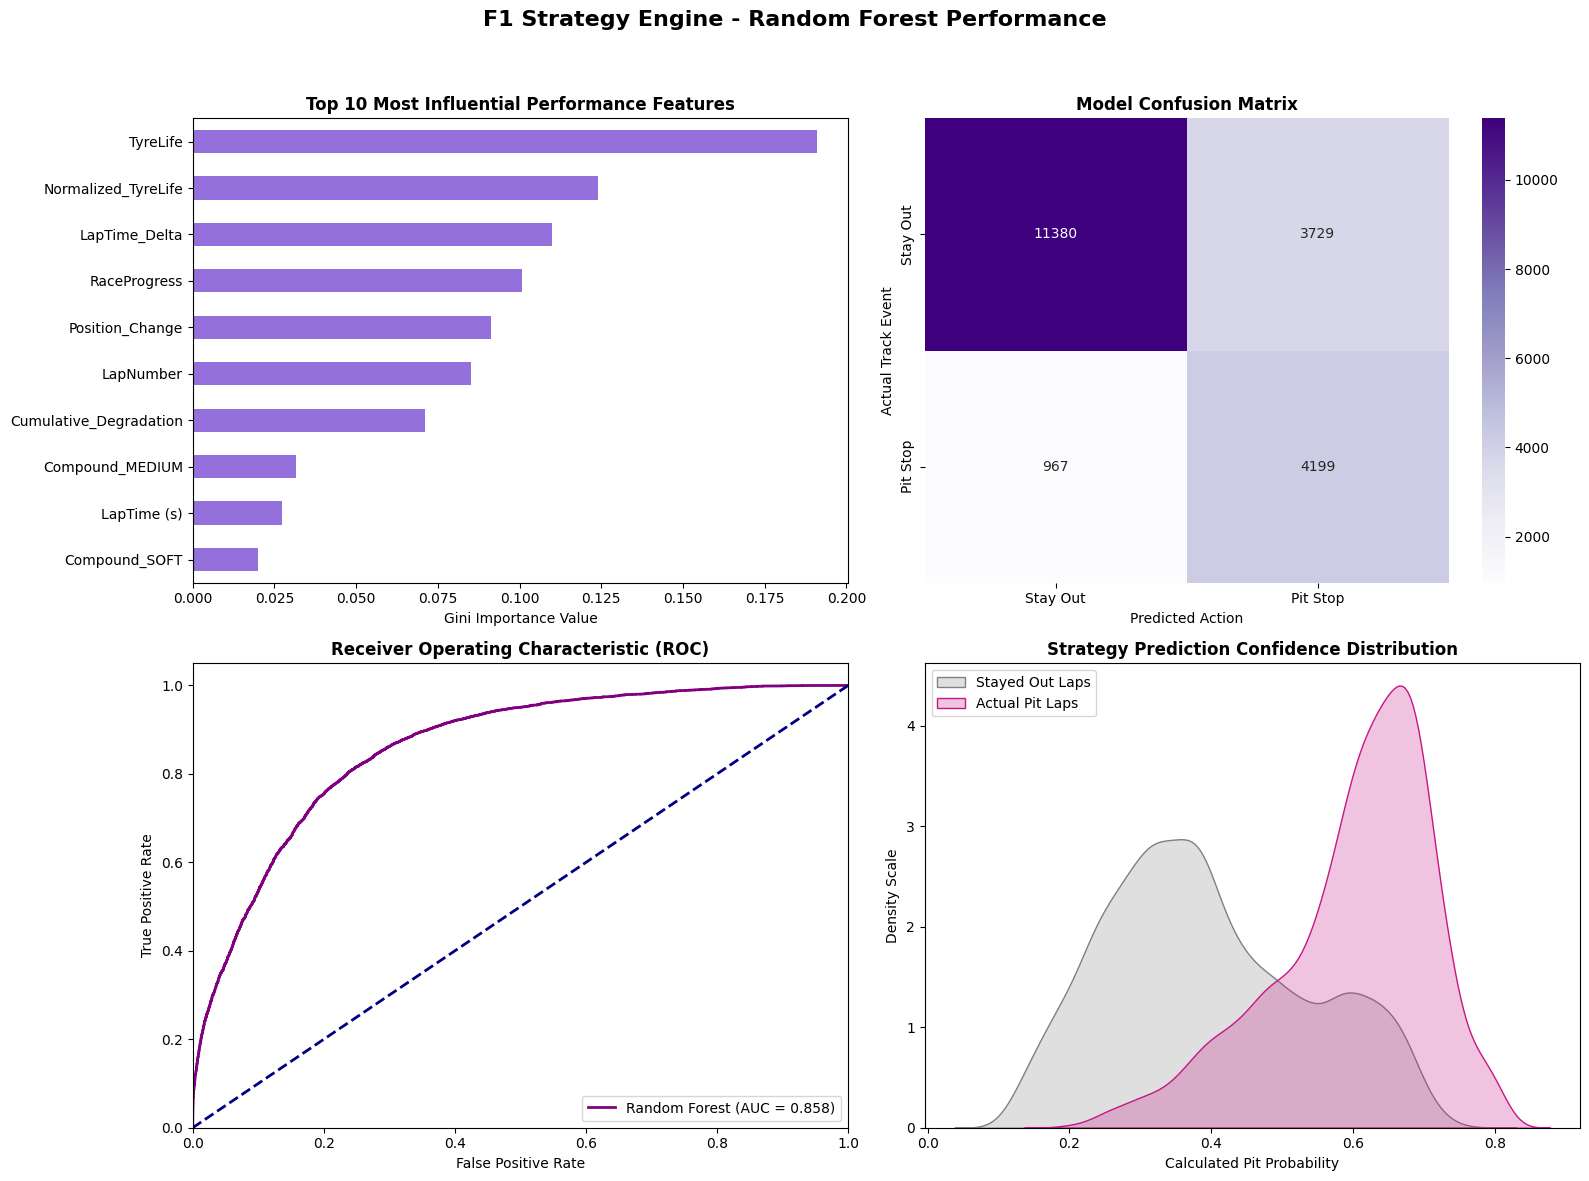

In [64]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
# ==========================================
# STEP 5: VISUAL DASHBOARD GENERATION
# ==========================================
print("\nStep 5: Drawing performance visualization dashboard...")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("F1 Strategy Engine - Random Forest Performance", fontsize=16, fontweight='bold')

# 1. Feature Importance Chart
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).sort_values().plot(kind='barh', ax=axes[0, 0], color='mediumpurple')
axes[0, 0].set_title("Top 10 Most Influential Performance Features", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Gini Importance Value")

# 2. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0, 1],
            xticklabels=['Stay Out', 'Pit Stop'], yticklabels=['Stay Out', 'Pit Stop'])
axes[0, 1].set_title("Model Confusion Matrix", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Predicted Action")
axes[0, 1].set_ylabel("Actual Track Event")

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
axes[1, 0].plot(fpr, tpr, color='purple', lw=2, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_probs):.3f})')
axes[1, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1, 0].set_xlim([0.0, 1.0])
axes[1, 0].set_ylim([0.0, 1.05])
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('Receiver Operating Characteristic (ROC)', fontsize=12, fontweight='bold')
axes[1, 0].legend(loc="lower right")

# 4. Probability Density Curve
sns.kdeplot(y_probs[y_test == 0], label='Stayed Out Laps', fill=True, ax=axes[1, 1], color='gray')
sns.kdeplot(y_probs[y_test == 1], label='Actual Pit Laps', fill=True, ax=axes[1, 1], color='mediumvioletred')
axes[1, 1].set_title("Strategy Prediction Confidence Distribution", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Calculated Pit Probability")
axes[1, 1].set_ylabel("Density Scale")
axes[1, 1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()